# IoT Network Traffic Schema-Based Data Generation

This notebook demonstrates a schema-based generation workflow for IoT network traffic data,
inspired by the MUDactivity behavior grammar framework from:

> **"Towards Behavior Grammar-Driven IoT Network Traffic Generation using MUD Specifications"**
> Zhang et al., CPSIoTSec '25, ACM CCS 2025

## Overview

The paper introduces **MUDactivity**, a behavior grammar that describes IoT network traffic patterns
through four key attributes:

1. **Packet count per flow** (`pkt-count`)
2. **Packet sizes per flow** (`pkt-size`)
3. **Packet inter-arrival times** (`pkt-iat`)
4. **Flow inter-arrival times** (`flow-iat`)

Each attribute can be modeled as:
- **Independent**: Generated from its own state machine
- **Dependent**: Generated based on another attribute's current state

This implementation uses **Rockfish's Entity Data Generator** to create synthetic IoT network
traffic data with realistic temporal patterns, state machines, and entity relationships.

## 1. Setup and Imports

In [1]:
import rockfish as rf
import rockfish.actions as ra
from rockfish.actions.ent import (
    CategoricalParams,
    Column,
    ColumnCategoryType,
    ColumnType,
    DataSchema,
    Derivation,
    DerivationFunctionType,
    Domain,
    DomainType,
    Entity,
    EntityRelationship,
    EntityRelationshipType,
    GlobalTimestamp,
    IDParams,
    MapValuesParams,
    NormalDistParams,
    SampleFromColumnParams,
    StateMachineParams,
    SumParams,
    TimeseriesParams,
    Timestamp,
    Transition,
    UniformDistParams,
    MultiplyParams,
)
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, HourLocator

In [2]:
def get_device_configs():
    """
    Return configuration for the 10 IoT devices studied in the paper.
    """
    return {
        "Amazon_Echo": {
            "flows": [
                {"endpoint": "dcape-na.amazon.com", "protocol": 6, "port": 443},
                {"endpoint": "device-metrics-us.amazon.com", "protocol": 6, "port": 443},
            ]
        },
        "Awair_Air_Quality": {
            "flows": [
                {"endpoint": "ota.awair.is", "protocol": 6, "port": 443},
                {"endpoint": "timeserver.awair.is", "protocol": 6, "port": 443},
                {"endpoint": "messaging.awair.is", "protocol": 6, "port": 8883},
            ]
        },
        "LIFX_Lightbulb": {
            "flows": [
                {"endpoint": "broker.lifx.co", "protocol": 6, "port": 8883},
            ]
        },
        "Pixstar_Photo_Frame": {
            "flows": [
                {"endpoint": "api.pixstar.com", "protocol": 6, "port": 443},
            ]
        },
        "Ring_Doorbell": {
            "flows": [
                {"endpoint": "fw.ring.com", "protocol": 6, "port": 443},
                {"endpoint": "ntp.ring.com", "protocol": 17, "port": 123},
            ]
        },
        "Samsung_Smartcam": {
            "flows": [
                {"endpoint": "samsungsmartcam.com", "protocol": 6, "port": 443},
            ]
        },
        "TPLink_Camera": {
            "flows": [
                {"endpoint": "n-devs.tplinkcloud.com", "protocol": 6, "port": 443},
            ]
        },
        "Triby_Speaker": {
            "flows": [
                {"endpoint": "triby.invoxia.io", "protocol": 6, "port": 443},
            ]
        },
        "Withings_Baby_Monitor": {
            "flows": [
                {"endpoint": "scalews.withings.com", "protocol": 6, "port": 443},
            ]
        },
        "Withings_Sleep_Sensor": {
            "flows": [
                {"endpoint": "scalews.withings.com", "protocol": 6, "port": 443},
            ]
        },
    }

In [8]:
def create_iot_device_schema(
    n_devices: int = 10,
    n_service_flows: int = 50,
    n_packets: int = 500,
    global_start_time: str = "2025-01-01T00:00:00Z",
    global_end_time: str = "2025-01-02T00:00:00Z",
    global_time_interval: str = "1min",
) -> DataSchema:
    """
    Create a comprehensive IoT network traffic schema based on MUDactivity concepts.
    """

    # ENTITY 1: iot_device
    iot_device = Entity(
        name="iot_device",
        cardinality=n_devices,
        columns=[
            Column(
                name="Device_ID",
                data_type="string",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.ID,
                    params=IDParams(template_str="IOT_DEV_{id}"),
                ),
            ),
            Column(
                name="Device_Type",
                data_type="string",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.CATEGORICAL,
                    params=CategoricalParams(
                        values=[
                            "Amazon_Echo",
                            "Awair_Air_Quality",
                            "LIFX_Lightbulb",
                            "Pixstar_Photo_Frame",
                            "Ring_Doorbell",
                            "Samsung_Smartcam",
                            "TPLink_Camera",
                            "Triby_Speaker",
                            "Withings_Baby_Monitor",
                            "Withings_Sleep_Sensor",
                        ],
                        with_replacement=True,
                        seed=100,
                    ),
                ),
            ),
            Column(
                name="MUD_URL",
                data_type="string",
                column_type=ColumnType.DERIVED,
                column_category_type=ColumnCategoryType.METADATA,
                derivation=Derivation(
                    function_type=DerivationFunctionType.MAP_VALUES,
                    dependent_columns=["Device_Type"],
                    params=MapValuesParams(
                        mapping=[
                            {"from": "Amazon_Echo", "to": "https://mud.amazon.com/echo"},
                            {"from": "Awair_Air_Quality", "to": "https://mud.awair.is/airquality"},
                            {"from": "LIFX_Lightbulb", "to": "https://mud.lifx.com/lightbulb"},
                            {"from": "Pixstar_Photo_Frame", "to": "https://mud.pixstar.com/frame"},
                            {"from": "Ring_Doorbell", "to": "https://mud.ring.com/doorbell"},
                            {"from": "Samsung_Smartcam", "to": "https://mud.samsung.com/smartcam"},
                            {"from": "TPLink_Camera", "to": "https://mud.tplink.com/camera"},
                            {"from": "Triby_Speaker", "to": "https://mud.triby.io/speaker"},
                            {"from": "Withings_Baby_Monitor", "to": "https://mud.withings.com/babymonitor"},
                            {"from": "Withings_Sleep_Sensor", "to": "https://mud.withings.com/sleepsensor"},
                        ],
                    ),
                ),
            ),
            Column(
                name="MAC_Address",
                data_type="string",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.ID,
                    params=IDParams(template_str="AA:BB:CC:DD:EE:{id}"),
                ),
            ),
            Column(
                name="IP_Address",
                data_type="string",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.ID,
                    params=IDParams(template_str="192.168.1.{id}"),
                ),
            ),
        ],
    )

    # ENTITY 2: service_flow
    service_flow = Entity(
        name="service_flow",
        cardinality=n_service_flows,
        timestamp=Timestamp(column_name="Flow_Timestamp", data_type="timestamp"),
        columns=[
            Column(
                name="Flow_ID",
                data_type="string",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.ID,
                    params=IDParams(template_str="FLOW_{id}"),
                ),
            ),
            Column(
                name="Device_ID",
                data_type="string",
                column_type=ColumnType.FOREIGN_KEY,
                column_category_type=ColumnCategoryType.METADATA,
            ),
            Column(
                name="Endpoint_Address",
                data_type="string",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.CATEGORICAL,
                    params=CategoricalParams(
                        values=[
                            "dcape-na.amazon.com",
                            "ota.awair.is",
                            "timeserver.awair.is",
                            "messaging.awair.is",
                            "broker.lifx.co",
                            "api.pixstar.com",
                            "fw.ring.com",
                            "samsungsmartcam.com",
                            "n-devs.tplinkcloud.com",
                            "triby.invoxia.io",
                            "scalews.withings.com",
                        ],
                        with_replacement=True,
                        seed=200,
                    ),
                ),
            ),
            Column(
                name="Transport_Protocol",
                data_type="int64",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.CATEGORICAL,
                    params=CategoricalParams(
                        values=[6, 17],
                        weights=[0.8, 0.2],
                        with_replacement=True,
                        seed=201,
                    ),
                ),
            ),
            Column(
                name="Transport_Port",
                data_type="int64",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.CATEGORICAL,
                    params=CategoricalParams(
                        values=[443, 8883, 80, 123, 53],
                        weights=[0.5, 0.2, 0.15, 0.1, 0.05],
                        with_replacement=True,
                        seed=202,
                    ),
                ),
            ),
            # Packet count per flow - state machine
            Column(
                name="Packet_Count",
                data_type="string",
                column_type=ColumnType.STATEFUL,
                column_category_type=ColumnCategoryType.MEASUREMENT,
                domain=Domain(
                    type=DomainType.STATE_MACHINE,
                    params=StateMachineParams(
                        trigger_column_name="Packet_Count_Trigger",
                        initial_state="normal_count",
                        states=["normal_count", "extended_count", "burst_count"],
                        terminal_states=[],
                        transitions=[
                            Transition(trigger="tick", source="normal_count", dest="extended_count", probability=0.44),
                            Transition(trigger="tick", source="normal_count", dest="normal_count", probability=0.50),
                            Transition(trigger="tick", source="normal_count", dest="burst_count", probability=0.06),
                            Transition(trigger="tick", source="extended_count", dest="normal_count", probability=0.56),
                            Transition(trigger="tick", source="extended_count", dest="extended_count", probability=0.37),
                            Transition(trigger="tick", source="extended_count", dest="burst_count", probability=0.07),
                            Transition(trigger="tick", source="burst_count", dest="normal_count", probability=0.80),
                            Transition(trigger="tick", source="burst_count", dest="extended_count", probability=0.20),
                        ],
                        column_name="Packet_Count",
                    ),
                ),
            ),
            # Flow IAT state
            Column(
                name="Flow_IAT_State",
                data_type="string",
                column_type=ColumnType.STATEFUL,
                column_category_type=ColumnCategoryType.MEASUREMENT,
                domain=Domain(
                    type=DomainType.STATE_MACHINE,
                    params=StateMachineParams(
                        trigger_column_name="Flow_IAT_Trigger",
                        initial_state="short_iat",
                        states=["short_iat", "long_iat"],
                        terminal_states=[],
                        transitions=[
                            Transition(trigger="tick", source="short_iat", dest="long_iat", probability=1.0),
                            Transition(trigger="tick", source="long_iat", dest="short_iat", probability=0.93),
                            Transition(trigger="tick", source="long_iat", dest="long_iat", probability=0.07),
                        ],
                        column_name="Flow_IAT_State",
                    ),
                ),
            ),
            # Flow IAT in milliseconds - timeseries
            Column(
                name="Flow_IAT_ms",
                data_type="float64",
                column_type=ColumnType.STATEFUL,
                column_category_type=ColumnCategoryType.MEASUREMENT,
                domain=Domain(
                    type=DomainType.TIMESERIES,
                    params=TimeseriesParams(
                        base_value=3300000.0,
                        min_value=60000.0,
                        max_value=21600000.0,
                        seasonality_type="peak_offpeak",
                        peak_start_hour=8,
                        peak_end_hour=22,
                        seasonality_strength=0.3,
                        noise_level=0.25,
                        spike_probability=0.05,
                        spike_magnitude=0.5,
                        interval_minutes=1,
                        seed=302,
                    ),
                ),
            ),
            # Total bytes transferred in flow
            Column(
                name="Flow_Bytes",
                data_type="int64",
                column_type=ColumnType.STATEFUL,
                column_category_type=ColumnCategoryType.MEASUREMENT,
                domain=Domain(
                    type=DomainType.TIMESERIES,
                    params=TimeseriesParams(
                        base_value=2500.0,
                        min_value=500.0,
                        max_value=15000.0,
                        seasonality_type="none",
                        noise_level=0.4,
                        spike_probability=0.08,
                        spike_magnitude=0.6,
                        interval_minutes=1,
                        seed=303,
                    ),
                ),
            ),
            # Flow duration in milliseconds
            Column(
                name="Flow_Duration_ms",
                data_type="float64",
                column_type=ColumnType.STATEFUL,
                column_category_type=ColumnCategoryType.MEASUREMENT,
                domain=Domain(
                    type=DomainType.TIMESERIES,
                    params=TimeseriesParams(
                        base_value=500.0,
                        min_value=50.0,
                        max_value=2000.0,
                        seasonality_type="none",
                        noise_level=0.3,
                        spike_probability=0.05,
                        spike_magnitude=0.4,
                        interval_minutes=1,
                        seed=304,
                    ),
                ),
            ),
        ],
    )

    # ENTITY 3: packet_activity
    packet_activity = Entity(
        name="packet_activity",
        cardinality=n_packets,
        timestamp=Timestamp(column_name="Packet_Timestamp", data_type="timestamp"),
        columns=[
            Column(
                name="Packet_ID",
                data_type="string",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.ID,
                    params=IDParams(template_str="PKT_{id}"),
                ),
            ),
            Column(
                name="Flow_ID",
                data_type="string",
                column_type=ColumnType.FOREIGN_KEY,
                column_category_type=ColumnCategoryType.METADATA,
            ),
            Column(
                name="Packet_Index",
                data_type="int64",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.CATEGORICAL,
                    params=CategoricalParams(
                        values=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                        weights=[0.18, 0.17, 0.16, 0.15, 0.14, 0.08, 0.05, 0.04, 0.02, 0.01],
                        with_replacement=True,
                        seed=400,
                    ),
                ),
            ),
            Column(
                name="Direction",
                data_type="int64",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.CATEGORICAL,
                    params=CategoricalParams(
                        values=[0, 1],
                        weights=[0.45, 0.55],
                        with_replacement=True,
                        seed=401,
                    ),
                ),
            ),
            # Packet size - state machine
            Column(
                name="Packet_Size",
                data_type="string",
                column_type=ColumnType.STATEFUL,
                column_category_type=ColumnCategoryType.MEASUREMENT,
                domain=Domain(
                    type=DomainType.STATE_MACHINE,
                    params=StateMachineParams(
                        trigger_column_name="Packet_Size_Trigger",
                        initial_state="small",
                        states=["small", "medium", "large", "max_mtu"],
                        terminal_states=[],
                        transitions=[
                            Transition(trigger="tick", source="small", dest="medium", probability=0.50),
                            Transition(trigger="tick", source="small", dest="large", probability=0.30),
                            Transition(trigger="tick", source="small", dest="small", probability=0.20),
                            Transition(trigger="tick", source="medium", dest="small", probability=0.35),
                            Transition(trigger="tick", source="medium", dest="large", probability=0.25),
                            Transition(trigger="tick", source="medium", dest="max_mtu", probability=0.15),
                            Transition(trigger="tick", source="medium", dest="medium", probability=0.25),
                            Transition(trigger="tick", source="large", dest="max_mtu", probability=0.40),
                            Transition(trigger="tick", source="large", dest="medium", probability=0.40),
                            Transition(trigger="tick", source="large", dest="small", probability=0.20),
                            Transition(trigger="tick", source="max_mtu", dest="medium", probability=0.50),
                            Transition(trigger="tick", source="max_mtu", dest="small", probability=0.40),
                            Transition(trigger="tick", source="max_mtu", dest="max_mtu", probability=0.10),
                        ],
                        column_name="Packet_Size",
                    ),
                ),
            ),
            # Packet IAT - timeseries
            Column(
                name="Packet_IAT_ms",
                data_type="float64",
                column_type=ColumnType.STATEFUL,
                column_category_type=ColumnCategoryType.MEASUREMENT,
                domain=Domain(
                    type=DomainType.TIMESERIES,
                    params=TimeseriesParams(
                        base_value=50.0,
                        min_value=1.0,
                        max_value=500.0,
                        seasonality_type="none",
                        noise_level=0.5,
                        spike_probability=0.1,
                        spike_magnitude=0.6,
                        interval_minutes=1,
                        seed=403,
                    ),
                ),
            ),
            Column(
                name="TCP_Flags",
                data_type="string",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.CATEGORICAL,
                    params=CategoricalParams(
                        values=["SYN", "SYN-ACK", "ACK", "PSH-ACK", "FIN-ACK", "RST"],
                        weights=[0.05, 0.05, 0.40, 0.40, 0.08, 0.02],
                        with_replacement=True,
                        seed=404,
                    ),
                ),
            ),
            Column(
                name="Has_Payload",
                data_type="int64",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.CATEGORICAL,
                    params=CategoricalParams(
                        values=[0, 1],
                        weights=[0.35, 0.65],
                        with_replacement=True,
                        seed=405,
                    ),
                ),
            ),
        ],
    )

    # ENTITY RELATIONSHIPS
    relationships = [
        EntityRelationship(
            parent_entity="iot_device",
            child_entity="service_flow",
            relationship_type=EntityRelationshipType.ONE_TO_MANY,
            join_columns={"Device_ID": "Device_ID"},
        ),
        EntityRelationship(
            parent_entity="service_flow",
            child_entity="packet_activity",
            relationship_type=EntityRelationshipType.ONE_TO_MANY,
            join_columns={"Flow_ID": "Flow_ID"},
        ),
    ]

    # GLOBAL TIMESTAMP
    global_timestamp = GlobalTimestamp(
        t_start=global_start_time,
        t_end=global_end_time,
        time_interval=global_time_interval,
    )

    return DataSchema(
        entities=[iot_device, service_flow, packet_activity],
        entity_relationships=relationships,
        global_timestamp=global_timestamp,
    )

In [9]:
def create_single_device_flow_schema(
    device_type: str = "Amazon_Echo",
    endpoint: str = "dcape-na.amazon.com",
    transport_protocol: int = 6,
    transport_port: int = 443,
    n_flows: int = 100,
    global_start_time: str = "2025-01-01T00:00:00Z",
    global_end_time: str = "2025-01-03T00:00:00Z",
    global_time_interval: str = "15min",
) -> DataSchema:
    """
    Create a focused schema for a single IoT device and its service flow.
    """

    mud_flow = Entity(
        name="mud_flow",
        cardinality=n_flows,
        timestamp=Timestamp(column_name="Timestamp", data_type="timestamp"),
        columns=[
            Column(
                name="Flow_Instance_ID",
                data_type="string",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.ID,
                    params=IDParams(template_str="FLOW_INST_{id}"),
                ),
            ),
            Column(
                name="Device_Type",
                data_type="string",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.CATEGORICAL,
                    params=CategoricalParams(
                        values=[device_type],
                        with_replacement=True,
                        seed=100,
                    ),
                ),
            ),
            Column(
                name="Endpoint_Address",
                data_type="string",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.CATEGORICAL,
                    params=CategoricalParams(
                        values=[endpoint],
                        with_replacement=True,
                        seed=101,
                    ),
                ),
            ),
            Column(
                name="Transport_Protocol",
                data_type="int64",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.CATEGORICAL,
                    params=CategoricalParams(
                        values=[transport_protocol],
                        with_replacement=True,
                        seed=102,
                    ),
                ),
            ),
            Column(
                name="Transport_Port",
                data_type="int64",
                column_type=ColumnType.INDEPENDENT,
                column_category_type=ColumnCategoryType.METADATA,
                domain=Domain(
                    type=DomainType.CATEGORICAL,
                    params=CategoricalParams(
                        values=[transport_port],
                        with_replacement=True,
                        seed=103,
                    ),
                ),
            ),
            # pkt-count: Packet count per flow - state machine
            Column(
                name="Pkt_Count",
                data_type="string",
                column_type=ColumnType.STATEFUL,
                column_category_type=ColumnCategoryType.MEASUREMENT,
                domain=Domain(
                    type=DomainType.STATE_MACHINE,
                    params=StateMachineParams(
                        trigger_column_name="Pkt_Count_Trigger",
                        initial_state="count_5",
                        states=["count_5", "count_6"],
                        terminal_states=[],
                        transitions=[
                            Transition(trigger="tick", source="count_5", dest="count_6", probability=0.56),
                            Transition(trigger="tick", source="count_5", dest="count_5", probability=0.44),
                            Transition(trigger="tick", source="count_6", dest="count_5", probability=0.93),
                            Transition(trigger="tick", source="count_6", dest="count_6", probability=0.07),
                        ],
                        column_name="Pkt_Count",
                    ),
                ),
            ),
            # flow-iat: Flow inter-arrival time state
            Column(
                name="Flow_IAT_State",
                data_type="string",
                column_type=ColumnType.STATEFUL,
                column_category_type=ColumnCategoryType.MEASUREMENT,
                domain=Domain(
                    type=DomainType.STATE_MACHINE,
                    params=StateMachineParams(
                        trigger_column_name="Flow_IAT_State_Trigger",
                        initial_state="delta_1",
                        states=["delta_1", "delta_2"],
                        terminal_states=[],
                        transitions=[
                            Transition(trigger="tick", source="delta_1", dest="delta_2", probability=1.0),
                            Transition(trigger="tick", source="delta_2", dest="delta_1", probability=0.93),
                            Transition(trigger="tick", source="delta_2", dest="delta_2", probability=0.07),
                        ],
                        column_name="Flow_IAT_State",
                    ),
                ),
            ),
            # flow-iat: Short IAT value (Δ1) in milliseconds
            Column(
                name="Flow_IAT_Short_ms",
                data_type="float64",
                column_type=ColumnType.STATEFUL,
                column_category_type=ColumnCategoryType.MEASUREMENT,
                domain=Domain(
                    type=DomainType.TIMESERIES,
                    params=TimeseriesParams(
                        base_value=200.0,
                        min_value=50.0,
                        max_value=500.0,
                        seasonality_type="none",
                        noise_level=0.3,
                        spike_probability=0.05,
                        spike_magnitude=0.3,
                        interval_minutes=15,
                        seed=202,
                    ),
                ),
            ),
            # flow-iat: Long IAT value (Δ2) in hours
            Column(
                name="Flow_IAT_Long_hours",
                data_type="float64",
                column_type=ColumnType.STATEFUL,
                column_category_type=ColumnCategoryType.MEASUREMENT,
                domain=Domain(
                    type=DomainType.TIMESERIES,
                    params=TimeseriesParams(
                        base_value=12.0,
                        min_value=1.0,
                        max_value=30.0,
                        seasonality_type="peak_offpeak",
                        peak_start_hour=0,
                        peak_end_hour=6,
                        seasonality_strength=0.2,
                        noise_level=0.4,
                        spike_probability=0.03,
                        spike_magnitude=0.5,
                        interval_minutes=15,
                        seed=203,
                    ),
                ),
            ),
            # pkt-iat: Average packet IAT within flow (milliseconds)
            Column(
                name="Avg_Pkt_IAT_ms",
                data_type="float64",
                column_type=ColumnType.STATEFUL,
                column_category_type=ColumnCategoryType.MEASUREMENT,
                domain=Domain(
                    type=DomainType.TIMESERIES,
                    params=TimeseriesParams(
                        base_value=80.0,
                        min_value=10.0,
                        max_value=400.0,
                        seasonality_type="none",
                        noise_level=0.45,
                        spike_probability=0.08,
                        spike_magnitude=0.4,
                        interval_minutes=15,
                        seed=204,
                    ),
                ),
            ),
            # pkt-size: Total bytes in flow
            Column(
                name="Total_Bytes",
                data_type="int64",
                column_type=ColumnType.STATEFUL,
                column_category_type=ColumnCategoryType.MEASUREMENT,
                domain=Domain(
                    type=DomainType.TIMESERIES,
                    params=TimeseriesParams(
                        base_value=2300.0,
                        min_value=800.0,
                        max_value=8000.0,
                        seasonality_type="none",
                        noise_level=0.35,
                        spike_probability=0.06,
                        spike_magnitude=0.5,
                        interval_minutes=15,
                        seed=205,
                    ),
                ),
            ),
            # Flow duration in milliseconds
            Column(
                name="Flow_Duration_ms",
                data_type="float64",
                column_type=ColumnType.STATEFUL,
                column_category_type=ColumnCategoryType.MEASUREMENT,
                domain=Domain(
                    type=DomainType.TIMESERIES,
                    params=TimeseriesParams(
                        base_value=400.0,
                        min_value=100.0,
                        max_value=1500.0,
                        seasonality_type="none",
                        noise_level=0.4,
                        spike_probability=0.05,
                        spike_magnitude=0.4,
                        interval_minutes=15,
                        seed=206,
                    ),
                ),
            ),
        ],
    )

    global_timestamp = GlobalTimestamp(
        t_start=global_start_time,
        t_end=global_end_time,
        time_interval=global_time_interval,
    )

    return DataSchema(
        entities=[mud_flow],
        entity_relationships=[],
        global_timestamp=global_timestamp,
    )

In [10]:
# Connect to the Rockfish platform using your API Key
load_dotenv()
conn = rf.Connection.from_env()

## 2. Understanding the MUDactivity Schema

The MUDactivity schema (Figure 5 in the paper) consists of two core sections:

### Flow-Info Section
```json
{
  "flow-info": {
    "device": "Amazon Echo",
    "mud-url": "https://mud.amazon.com/echo",
    "flow-name": "tcp-443-dcape",
    "endpoint-addr": "dcape-na.amazon.com",
    "transport-protocol": 6,
    "transport-port": 443
  }
}
```

### Flow-Activity Section
```json
{
  "flow-activity": {
    "pkt-count": [state-machine],
    "pkt-size": [state-machine],
    "pkt-iat": [state-machine],
    "flow-iat": [state-machine]
  }
}
```

Each attribute is modeled with states and transitions, where states can be:
- **Distribution**: Probabilistic (e.g., Folded Cauchy, Exponential)
- **Deterministic**: Fixed values or patterns

## 3. IoT Devices Studied

The paper analyzed traffic from 10 commercial IoT devices:

In [11]:
# Display the device configurations
device_configs = get_device_configs()

print("IoT Devices and Their Service Flows:")
print("=" * 60)
for device, config in device_configs.items():
    print(f"\n{device}:")
    for flow in config['flows']:
        proto = "TCP" if flow['protocol'] == 6 else "UDP"
        print(f"  - {proto}/{flow['port']} -> {flow['endpoint']}")

IoT Devices and Their Service Flows:

Amazon_Echo:
  - TCP/443 -> dcape-na.amazon.com
  - TCP/443 -> device-metrics-us.amazon.com

Awair_Air_Quality:
  - TCP/443 -> ota.awair.is
  - TCP/443 -> timeserver.awair.is
  - TCP/8883 -> messaging.awair.is

LIFX_Lightbulb:
  - TCP/8883 -> broker.lifx.co

Pixstar_Photo_Frame:
  - TCP/443 -> api.pixstar.com

Ring_Doorbell:
  - TCP/443 -> fw.ring.com
  - UDP/123 -> ntp.ring.com

Samsung_Smartcam:
  - TCP/443 -> samsungsmartcam.com

TPLink_Camera:
  - TCP/443 -> n-devs.tplinkcloud.com

Triby_Speaker:
  - TCP/443 -> triby.invoxia.io

Withings_Baby_Monitor:
  - TCP/443 -> scalews.withings.com

Withings_Sleep_Sensor:
  - TCP/443 -> scalews.withings.com


## 4. Create the IoT Network Schema

We'll create a comprehensive schema with three entities:

1. **iot_device**: Individual IoT devices (maps to MUD device identifier)
2. **service_flow**: MUD service flows with flow-level behaviors
3. **packet_activity**: Packet-level measurements within flows

In [12]:
# Create the comprehensive IoT network schema
iot_schema = create_iot_device_schema(
    n_devices=10,          # 10 IoT devices (matching the paper)
    n_service_flows=50,    # 50 service flows across all devices
    n_packets=500,         # 500 packet activity records
    global_start_time="2025-01-01T00:00:00Z",
    global_end_time="2025-01-02T00:00:00Z",
    global_time_interval="1min",
)

print(f"Schema created with {len(iot_schema.entities)} entities:")
for entity in iot_schema.entities:
    print(f"  - {entity.name}: {entity.cardinality} instances, {len(entity.columns)} columns")

Schema created with 3 entities:
  - iot_device: 10 instances, 5 columns
  - service_flow: 50 instances, 10 columns
  - packet_activity: 500 instances, 8 columns


## 5. Run Data Generation

We use a Rockfish Workflow to generate synthetic data from the schema.

In [13]:
# Configure the data generation action
config = ra.GenerateFromDataSchema.Config(
    schema=iot_schema,
    upload_datasets=True,
)
generate = ra.GenerateFromDataSchema(config)

In [14]:
# Start the workflow
builder = rf.WorkflowBuilder()
builder.add(generate)
workflow = await builder.start(conn)
print(f"Workflow ID: {workflow.id()}")

Workflow ID: 3LOhh3V1fIYP3GQncyWGI9


In [15]:
# Monitor workflow progress
async for log in workflow.logs(level=rf.events.LogLevel.DEBUG):
    print(log)

2026-02-24T17:18:00.320082Z generate-from-data-schema: INFO Generating 3 entities: iot_device, service_flow, packet_activity
2026-02-24T17:18:00.331510Z generate-from-data-schema: INFO Starting data generation...
2026-02-24T17:18:37.598706Z generate-from-data-schema: INFO Generated 3 entity tables
2026-02-24T17:18:37.623695Z generate-from-data-schema: INFO Creating dataset for entity 'iot_device': 10 rows
2026-02-24T17:18:37.932855Z generate-from-data-schema: INFO Uploaded dataset 'iot_device' (5qakTJOlAOgQ8H2utglgcJ): 10 rows
2026-02-24T17:18:37.953912Z generate-from-data-schema: INFO Creating dataset for entity 'service_flow': 72050 rows
2026-02-24T17:18:38.206536Z generate-from-data-schema: INFO Uploaded dataset 'service_flow' (2pVyiCIf80c7BmywRVH9h7): 72050 rows
2026-02-24T17:18:38.229210Z generate-from-data-schema: INFO Creating dataset for entity 'packet_activity': 720500 rows
2026-02-24T17:18:38.864459Z generate-from-data-schema: INFO Uploaded dataset 'packet_activity' (1f7xG6cm

## 6. Retrieve and Explore Generated Datasets

In [16]:
# Retrieve all generated datasets
datasets = await workflow.datasets().collect()
print(f"Generated {len(datasets)} datasets")

iot_device_df = None
service_flow_df = None
packet_activity_df = None

for remote_ds in datasets:
    ds = await remote_ds.to_local(conn)
    if ds.name() == "iot_device":
        iot_device_df = ds.to_pandas()
    elif ds.name() == "service_flow":
        service_flow_df = ds.to_pandas()
    elif ds.name() == "packet_activity":
        packet_activity_df = ds.to_pandas()

Generated 3 datasets


### 6.1 IoT Device Data

In [17]:
print(f"IoT Device dataset: {len(iot_device_df)} rows")
iot_device_df.head(10)

IoT Device dataset: 10 rows


,Device_ID,Device_Type,MUD_URL,MAC_Address,IP_Address
0,IOT_DEV_0,Triby_Speaker,https://mud.triby.io/speaker,AA:BB:CC:DD:EE:0,192.168.1.0
1,IOT_DEV_1,Withings_Baby_Monitor,https://mud.withings.com/babymonitor,AA:BB:CC:DD:EE:1,192.168.1.1
2,IOT_DEV_2,Awair_Air_Quality,https://mud.awair.is/airquality,AA:BB:CC:DD:EE:2,192.168.1.2
3,IOT_DEV_3,Samsung_Smartcam,https://mud.samsung.com/smartcam,AA:BB:CC:DD:EE:3,192.168.1.3
4,IOT_DEV_4,Amazon_Echo,https://mud.amazon.com/echo,AA:BB:CC:DD:EE:4,192.168.1.4
5,IOT_DEV_5,LIFX_Lightbulb,https://mud.lifx.com/lightbulb,AA:BB:CC:DD:EE:5,192.168.1.5
6,IOT_DEV_6,Ring_Doorbell,https://mud.ring.com/doorbell,AA:BB:CC:DD:EE:6,192.168.1.6
7,IOT_DEV_7,Amazon_Echo,https://mud.amazon.com/echo,AA:BB:CC:DD:EE:7,192.168.1.7
8,IOT_DEV_8,Samsung_Smartcam,https://mud.samsung.com/smartcam,AA:BB:CC:DD:EE:8,192.168.1.8
9,IOT_DEV_9,Withings_Sleep_Sensor,https://mud.withings.com/sleepsensor,AA:BB:CC:DD:EE:9,192.168.1.9


In [18]:
# Device type distribution
print("\nDevice Type Distribution:")
print(iot_device_df['Device_Type'].value_counts())


Device Type Distribution:
Device_Type
Samsung_Smartcam         2
Amazon_Echo              2
Triby_Speaker            1
Withings_Baby_Monitor    1
Awair_Air_Quality        1
LIFX_Lightbulb           1
Ring_Doorbell            1
Withings_Sleep_Sensor    1
Name: count, dtype: int64


### 6.2 Service Flow Data (MUD ACE Entries)

In [19]:
print(f"Service Flow dataset: {len(service_flow_df)} rows")
service_flow_df.head(10)

Service Flow dataset: 72050 rows


,Flow_ID,Device_ID,Endpoint_Address,Transport_Protocol,Transport_Port,Packet_Count,Packet_Count_Trigger,Flow_IAT_State,Flow_IAT_Trigger,Flow_IAT_ms,Flow_Bytes,Flow_Duration_ms,Flow_Timestamp
0,FLOW_0,IOT_DEV_8,dcape-na.amazon.com,17,443,normal_count,None,short_iat,None,1.020501e+07,1767,605.674219,2025-01-01T00:00:00+00:00
1,FLOW_0,IOT_DEV_8,dcape-na.amazon.com,17,443,normal_count,tick,long_iat,tick,9.940189e+06,3078,506.237872,2025-01-01T00:01:00+00:00
2,FLOW_0,IOT_DEV_8,dcape-na.amazon.com,17,443,extended_count,tick,short_iat,tick,1.046433e+07,3786,490.717401,2025-01-01T00:02:00+00:00
3,FLOW_0,IOT_DEV_8,dcape-na.amazon.com,17,443,normal_count,tick,long_iat,tick,9.029811e+06,3067,551.249189,2025-01-01T00:03:00+00:00
4,FLOW_0,IOT_DEV_8,dcape-na.amazon.com,17,443,extended_count,tick,short_iat,tick,1.110429e+07,1781,428.506141,2025-01-01T00:04:00+00:00
5,FLOW_0,IOT_DEV_8,dcape-na.amazon.com,17,443,extended_count,tick,long_iat,tick,8.497081e+06,3948,332.159772,2025-01-01T00:05:00+00:00
6,FLOW_0,IOT_DEV_8,dcape-na.amazon.com,17,443,extended_count,tick,short_iat,tick,8.227787e+06,2518,524.612102,2025-01-01T00:06:00+00:00
7,FLOW_0,IOT_DEV_8,dcape-na.amazon.com,17,443,extended_count,tick,long_iat,tick,9.080537e+06,1574,527.070302,2025-01-01T00:07:00+00:00
8,FLOW_0,IOT_DEV_8,dcape-na.amazon.com,17,443,extended_count,tick,short_iat,tick,8.867393e+06,2783,50.000000,2025-01-01T00:08:00+00:00
9,FLOW_0,IOT_DEV_8,dcape-na.amazon.com,17,443,normal_count,tick,long_iat,tick,8.644485e+06,1230,514.064483,2025-01-01T00:09:00+00:00


In [20]:
# Flow statistics - matching MUDactivity attributes
print("\nPacket Count Distribution (pkt-count from MUDactivity):")
print(service_flow_df['Packet_Count'].value_counts().sort_index())

print("\nFlow IAT State Distribution (flow-iat states):")
print(service_flow_df['Flow_IAT_State'].value_counts())

print("\nTransport Protocol Distribution:")
proto_map = {6: 'TCP', 17: 'UDP'}
print(service_flow_df['Transport_Protocol'].map(proto_map).value_counts())

print("\nTransport Port Distribution:")
print(service_flow_df['Transport_Port'].value_counts())


Packet Count Distribution (pkt-count from MUDactivity):
Packet_Count
burst_count        4352
extended_count    28605
normal_count      39093
Name: count, dtype: int64

Flow IAT State Distribution (flow-iat states):
Flow_IAT_State
long_iat     37290
short_iat    34760
Name: count, dtype: int64

Transport Protocol Distribution:
Transport_Protocol
TCP    64845
UDP     7205
Name: count, dtype: int64

Transport Port Distribution:
Transport_Port
443     37466
8883    21615
80       5764
123      5764
53       1441
Name: count, dtype: int64


### 6.3 Packet Activity Data

In [21]:
print(f"Packet Activity dataset: {len(packet_activity_df)} rows")
packet_activity_df.head(10)

Packet Activity dataset: 720500 rows


,Packet_ID,Flow_ID,Packet_Index,Direction,Packet_Size,Packet_Size_Trigger,Packet_IAT_ms,TCP_Flags,Has_Payload,Packet_Timestamp
0,PKT_0,FLOW_42,2,1,small,None,62.081707,ACK,1,2025-01-01T00:00:00+00:00
1,PKT_0,FLOW_42,2,1,large,tick,8.703213,ACK,1,2025-01-01T00:01:00+00:00
2,PKT_0,FLOW_42,2,1,max_mtu,tick,1.000000,ACK,1,2025-01-01T00:02:00+00:00
3,PKT_0,FLOW_42,2,1,medium,tick,71.894333,ACK,1,2025-01-01T00:03:00+00:00
4,PKT_0,FLOW_42,2,1,small,tick,74.142918,ACK,1,2025-01-01T00:04:00+00:00
5,PKT_0,FLOW_42,2,1,small,tick,1.000000,ACK,1,2025-01-01T00:05:00+00:00
6,PKT_0,FLOW_42,2,1,small,tick,13.471244,ACK,1,2025-01-01T00:06:00+00:00
7,PKT_0,FLOW_42,2,1,large,tick,99.404121,ACK,1,2025-01-01T00:07:00+00:00
8,PKT_0,FLOW_42,2,1,medium,tick,40.744493,ACK,1,2025-01-01T00:08:00+00:00
9,PKT_0,FLOW_42,2,1,large,tick,44.885660,ACK,1,2025-01-01T00:09:00+00:00


In [22]:
# Packet statistics - matching MUDactivity pkt-size attribute
print("\nPacket Size Distribution (pkt-size from MUDactivity):")
print(packet_activity_df['Packet_Size'].value_counts().sort_index())

print("\nTCP Flags Distribution:")
print(packet_activity_df['TCP_Flags'].value_counts())


Packet Size Distribution (pkt-size from MUDactivity):
Packet_Size
large      131700
max_mtu    104420
medium     277239
small      207141
Name: count, dtype: int64

TCP Flags Distribution:
TCP_Flags
ACK        289641
PSH-ACK    280995
FIN-ACK     56199
SYN         40348
SYN-ACK     30261
RST         23056
Name: count, dtype: int64


## 7. Visualize Flow-Level Metrics

These visualizations correspond to the four key attributes in MUDactivity:
- Packet count per flow
- Packet sizes
- Packet IAT
- Flow IAT

In [23]:
def plot_metric_distribution(data, column, title, xlabel, bins=20):
    """Plot distribution of a metric."""
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(data[column].dropna(), bins=bins, edgecolor='black', alpha=0.7)
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    return fig

def plot_metric_over_time(df, metric_col, timestamp_col, title):
    """Plot a metric over time."""
    plot_df = df[[timestamp_col, metric_col]].copy().sort_values(timestamp_col)
    plot_df[timestamp_col] = pd.to_datetime(plot_df[timestamp_col])
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(plot_df[timestamp_col], plot_df[metric_col], linewidth=1.5, alpha=0.8)
    ax.set_xlabel(timestamp_col, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric_col, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    return fig

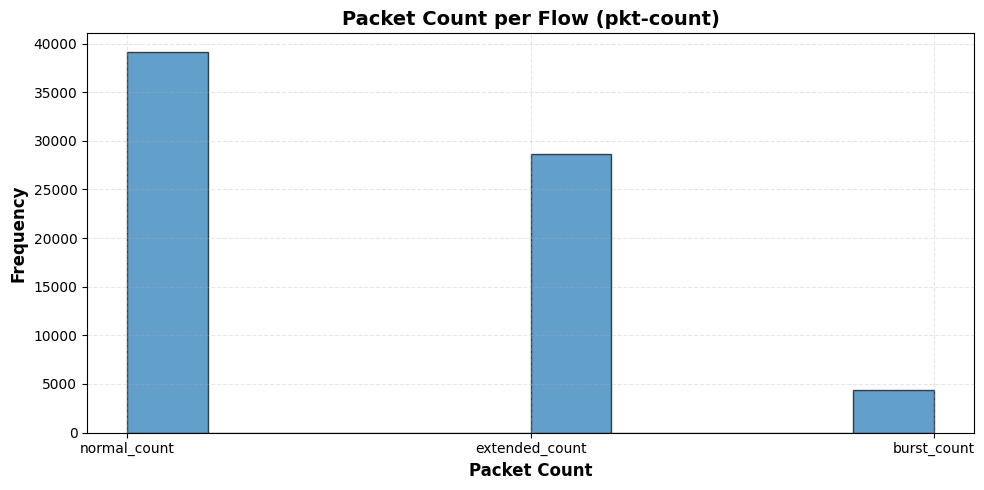

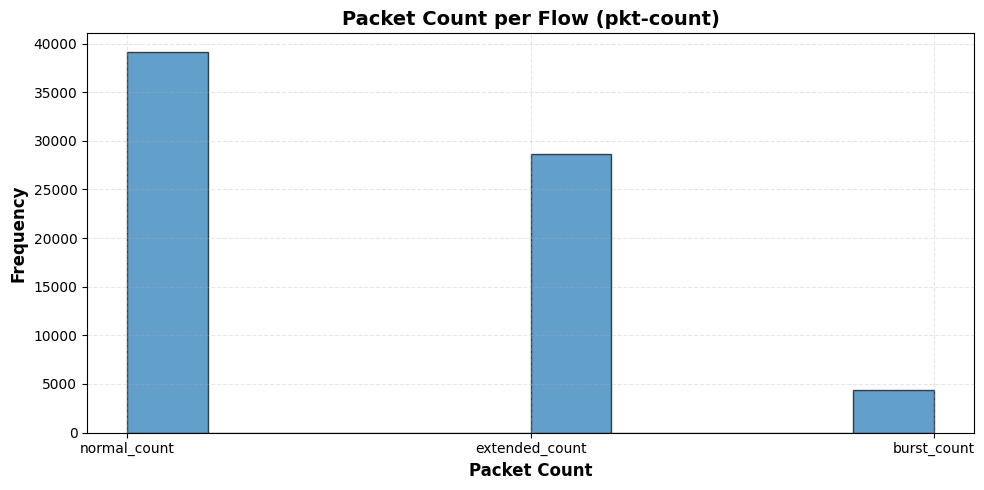

In [24]:
# Plot 1: Packet Count Distribution (Figure 2a from paper)
plot_metric_distribution(
    service_flow_df, 
    'Packet_Count', 
    'Packet Count per Flow (pkt-count)',
    'Packet Count',
    bins=10
)

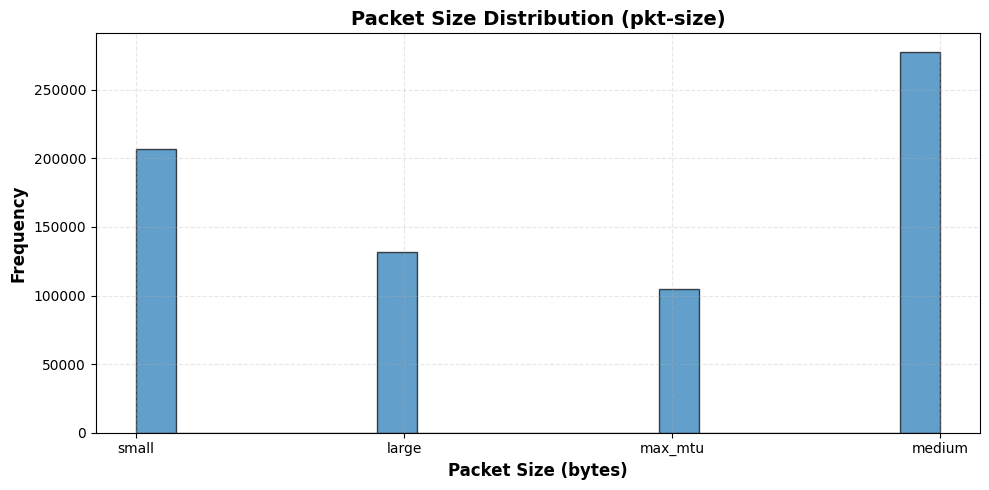

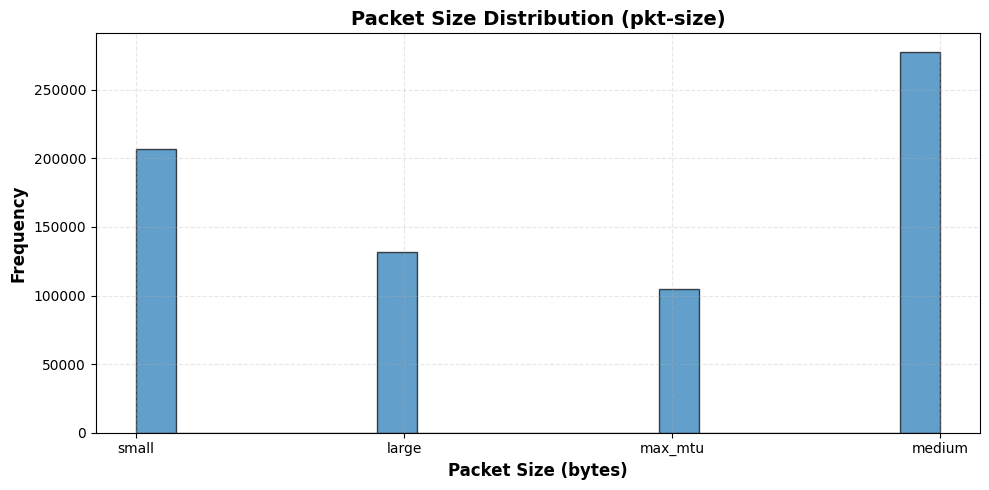

In [25]:
# Plot 2: Packet Size Distribution (Figure 2b from paper)
plot_metric_distribution(
    packet_activity_df, 
    'Packet_Size', 
    'Packet Size Distribution (pkt-size)',
    'Packet Size (bytes)',
    bins=20
)

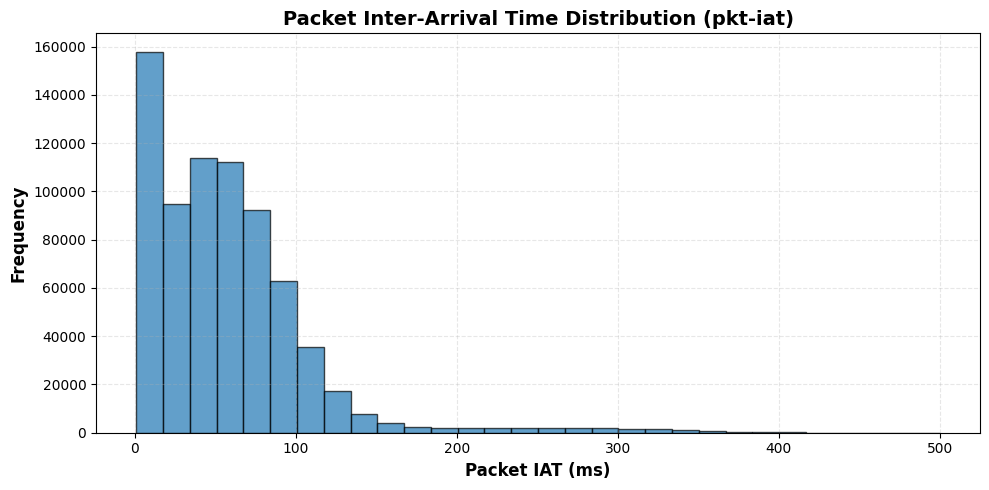

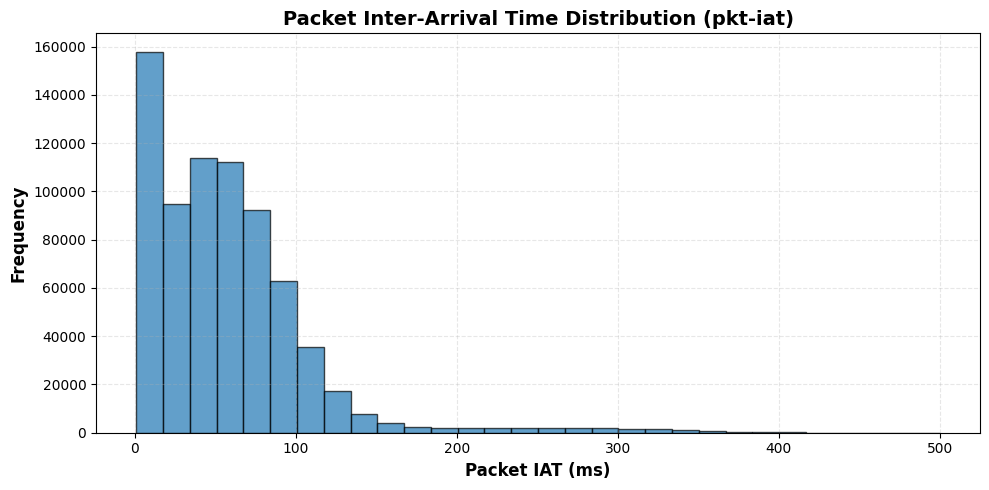

In [26]:
# Plot 3: Packet IAT Distribution (Figure 2c from paper)
plot_metric_distribution(
    packet_activity_df, 
    'Packet_IAT_ms', 
    'Packet Inter-Arrival Time Distribution (pkt-iat)',
    'Packet IAT (ms)',
    bins=30
)

In [ ]:
# Plot 4: Flow IAT Over Time (Figure 2d from paper)
plot_metric_over_time(
    service_flow_df,
    'Flow_IAT_ms',
    'Flow_Timestamp',
    'Flow Inter-Arrival Time Over Time (flow-iat)'
)

In [ ]:
# Plot 5: Flow Bytes Over Time
plot_metric_over_time(
    service_flow_df,
    'Flow_Bytes',
    'Flow_Timestamp',
    'Flow Bytes Over Time'
)

## 8. Generate Data for a Single Device Flow

This section demonstrates generating data for a specific MUD service flow,
similar to the Amazon Echo TCP/443 flow analyzed in the paper.

In [ ]:
# Create schema for Amazon Echo TCP/443 flow (from paper)
amazon_echo_schema = create_single_device_flow_schema(
    device_type="Amazon_Echo",
    endpoint="dcape-na.amazon.com",
    transport_protocol=6,  # TCP
    transport_port=443,
    n_flows=150,  # Match paper's 150 flow instances
    global_start_time="2025-01-01T00:00:00Z",
    global_end_time="2025-01-03T00:00:00Z",
    global_time_interval="15min",
)

print(f"Single device schema created:")
for entity in amazon_echo_schema.entities:
    print(f"  - {entity.name}: {entity.cardinality} instances, {len(entity.columns)} columns")

In [ ]:
# Generate data for the single device flow
single_config = ra.GenerateFromDataSchema.Config(
    schema=amazon_echo_schema,
    upload_datasets=True,
)
single_generate = ra.GenerateFromDataSchema(single_config)

single_builder = rf.WorkflowBuilder()
single_builder.add(single_generate)
single_workflow = await single_builder.start(conn)
print(f"Single Device Workflow ID: {single_workflow.id()}")

In [ ]:
# Monitor workflow
async for log in single_workflow.logs(level=rf.events.LogLevel.DEBUG):
    print(log)

In [ ]:
# Retrieve the single device flow data
single_datasets = await single_workflow.datasets().collect()
mud_flow_df = None

for remote_ds in single_datasets:
    ds = await remote_ds.to_local(conn)
    if ds.name() == "mud_flow":
        mud_flow_df = ds.to_pandas()

print(f"MUD Flow dataset: {len(mud_flow_df)} rows")
mud_flow_df.head()

In [ ]:
# Analyze the MUDactivity attributes
print("\n" + "="*60)
print("MUDactivity Attribute Analysis for Amazon Echo TCP/443")
print("="*60)

print("\n1. Packet Count (pkt-count) Distribution:")
print(mud_flow_df['Pkt_Count'].value_counts().sort_index())

print("\n2. Flow IAT State Distribution:")
print(mud_flow_df['Flow_IAT_State'].value_counts())

print("\n3. Flow IAT Statistics (short, ms):")
print(mud_flow_df['Flow_IAT_Short_ms'].describe())

print("\n4. Flow IAT Statistics (long, hours):")
print(mud_flow_df['Flow_IAT_Long_hours'].describe())

print("\n5. Average Packet IAT Statistics (ms):")
print(mud_flow_df['Avg_Pkt_IAT_ms'].describe())

print("\n6. Total Bytes Statistics:")
print(mud_flow_df['Total_Bytes'].describe())

In [ ]:
# Plot MUDactivity attributes (matching Figure 4 from paper)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Packet Count Distribution
ax1 = axes[0, 0]
mud_flow_df['Pkt_Count'].value_counts().sort_index().plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_xlabel('Packet Count', fontweight='bold')
ax1.set_ylabel('Frequency', fontweight='bold')
ax1.set_title('(a) Data Packet Count per Flow', fontweight='bold')
ax1.tick_params(axis='x', rotation=0)

# Plot 2: Short Flow IAT Distribution
ax2 = axes[0, 1]
ax2.hist(mud_flow_df['Flow_IAT_Short_ms'].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Flow IAT (ms)', fontweight='bold')
ax2.set_ylabel('Frequency', fontweight='bold')
ax2.set_title('(c) Δ1: Short Flow IAT Distribution', fontweight='bold')

# Plot 3: Long Flow IAT Distribution
ax3 = axes[1, 0]
ax3.hist(mud_flow_df['Flow_IAT_Long_hours'].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Flow IAT (hours)', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.set_title('(d) Δ2: Long Flow IAT Distribution', fontweight='bold')

# Plot 4: Packet IAT Distribution
ax4 = axes[1, 1]
ax4.hist(mud_flow_df['Avg_Pkt_IAT_ms'].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax4.set_xlabel('Packet IAT (ms)', fontweight='bold')
ax4.set_ylabel('Frequency', fontweight='bold')
ax4.set_title('Packet Inter-Arrival Time Distribution', fontweight='bold')

for ax in axes.flat:
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.suptitle('MUDactivity Attributes for Amazon Echo TCP/443 Flow', fontsize=14, fontweight='bold', y=1.02)
plt.show()

## 9. Validate Entity Relationships

Verify that foreign key relationships are properly maintained.

In [ ]:
# Validate iot_device -> service_flow relationship
device_ids_in_devices = set(iot_device_df['Device_ID'].unique())
device_ids_in_flows = set(service_flow_df['Device_ID'].unique())

print("Relationship Validation:")
print("=" * 50)
print(f"\niot_device -> service_flow:")
print(f"  Valid device IDs: {len(device_ids_in_devices)}")
print(f"  Device IDs in flows: {len(device_ids_in_flows)}")
print(f"  All flow device IDs valid: {device_ids_in_flows.issubset(device_ids_in_devices)}")

# Validate service_flow -> packet_activity relationship
flow_ids_in_flows = set(service_flow_df['Flow_ID'].unique())
flow_ids_in_packets = set(packet_activity_df['Flow_ID'].unique())

print(f"\nservice_flow -> packet_activity:")
print(f"  Valid flow IDs: {len(flow_ids_in_flows)}")
print(f"  Flow IDs in packets: {len(flow_ids_in_packets)}")
print(f"  All packet flow IDs valid: {flow_ids_in_packets.issubset(flow_ids_in_flows)}")

## 10. Save Generated Data

In [ ]:
# Save all datasets to CSV
iot_device_df.to_csv("iot_device_data.csv", index=False)
service_flow_df.to_csv("service_flow_data.csv", index=False)
packet_activity_df.to_csv("packet_activity_data.csv", index=False)
mud_flow_df.to_csv("amazon_echo_mud_flow_data.csv", index=False)

print("Data saved successfully:")
print("  - iot_device_data.csv")
print("  - service_flow_data.csv")
print("  - packet_activity_data.csv")
print("  - amazon_echo_mud_flow_data.csv")

## 11. Conclusion

This notebook demonstrated how to implement the MUDactivity behavior grammar framework
using Rockfish's schema-based data generation capabilities.

### Key Features Implemented:

1. **MUDactivity Schema Mapping**:
   - `flow-info` section → `iot_device` and `service_flow` entities
   - `flow-activity` attributes → Stateful columns with state machines

2. **State Machine Behaviors**:
   - Packet count alternating between states (e.g., 5 and 6 packets)
   - Flow IAT with short (Δ1) and long (Δ2) states
   - Packet size patterns based on observed traffic

3. **Temporal Patterns**:
   - Timeseries generation with seasonality (peak/off-peak hours)
   - Noise and spike modeling for realistic variability

4. **Entity Relationships**:
   - Device → Service Flow (one-to-many)
   - Service Flow → Packet Activity (one-to-many)

### References:

- Zhang et al., "Towards Behavior Grammar-Driven IoT Network Traffic Generation using MUD Specifications", CPSIoTSec '25, ACM CCS 2025
- IETF MUD Standard: RFC 8520
- Rockfish Entity Data Generator Documentation: https://docs.rockfish.ai/sdk/actions-ent.html